# CNN vs MLP Diagnostics

Two targeted tests to determine whether the CNN's 127-position receptive field
actually contributes beyond what the per-position MLP already achieves:

1. **Permutation test** — shuffle input positions; MLP accuracy is invariant by
   construction, CNN accuracy should drop if it was using sequential context.
2. **Confidence at error positions** — at positions each model gets wrong, compare
   the max softmax confidence. A model using context should be less confident at
   its remaining errors (better uncertainty calibration).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import torch
import torch.nn.functional as F
import h5py
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from torch.utils.data import DataLoader
from models.conv_denoiser import ConvDenoiser
from models.single_shot import (
    SingleShotDenoiserA, ProteinDataset, collate_fn
)
from models.properties import AA_ORDER

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

H5_PATH  = Path('../data/synthetic/perturbed_n1000_seed42.h5')
CKPT_DIR = Path('../models/checkpoints')
DEVICE   = 'cpu'
N_PERM   = 20    # permutation trials per protein
BATCH    = 32

aa_to_idx = {aa: i for i, aa in enumerate(AA_ORDER)}

# Reproducible val split — must match training
with h5py.File(H5_PATH, 'r') as f:
    all_pids = list(f.keys())
rng      = np.random.default_rng(42)
pids     = rng.permutation(all_pids).tolist()
val_pids = pids[int(len(pids) * 0.8):]
print(f'Val proteins: {len(val_pids)}')

Val proteins: 200


In [2]:
DATASETS = [
    'perturb_gamma3', 'perturb_gamma1',
    'scramble_10pct', 'scramble_20pct',
    'lowconf_10pct',  'lowconf_20pct',
]
LABELS = [
    'γ=3', 'γ=1',
    's=10%', 's=20%',
    'lc=10%', 'lc=20%',
]

def load_mlp(dataset_key):
    """Load SingleShotDenoiserA from its per-dataset checkpoint.
    prop_mean/prop_std are saved as buffers — no fit_stats needed."""
    m = SingleShotDenoiserA(hidden_dim=128, n_layers=2, dropout=0.1).to(DEVICE)
    ckpt = CKPT_DIR / f'single_shot_{dataset_key}_SingleShotDenoiserA.pt'
    m.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    m.eval()
    return m

def load_cnn(dataset_key):
    m = ConvDenoiser(d=128).to(DEVICE)
    m.load_state_dict(torch.load(CKPT_DIR / f'conv_denoiser_{dataset_key}.pt', map_location=DEVICE))
    m.eval()
    return m

## Test 1 — Permutation Test

For each protein, run both models on the original sequence and on `N_PERM`
independently shuffled versions. Position permutation destroys all sequential
context while preserving the marginal distribution of input vectors.

- MLP is position-invariant → accuracy **must** be identical under permutation.
- CNN uses a 127-position receptive field → accuracy **should drop** if context matters.

The gap `acc_orig − acc_perm` is a direct measure of how much the receptive field contributes.

In [3]:
@torch.no_grad()
def permutation_test(model, dataset_key, n_trials=N_PERM):
    """
    Returns (acc_orig, acc_perm) averaged over the val set.
    Uses batch_size=1 so there is never any padding — permutation
    is applied cleanly within the true sequence length.
    """
    ds  = ProteinDataset(H5_PATH, dataset_key, val_pids, aa_to_idx)
    ldr = DataLoader(ds, batch_size=1, shuffle=False, collate_fn=collate_fn)

    correct_orig = correct_perm = total = 0

    for probs, labels in ldr:
        probs  = probs.to(DEVICE)   # (1, L, 20)
        labels = labels.to(DEVICE)  # (1, L)  — no -1 padding at batch_size=1
        L = probs.shape[1]

        # Original
        preds = model(probs).argmax(-1)
        correct_orig += (preds == labels).sum().item()
        total += L

        # Permuted trials — permute input AND labels together
        for _ in range(n_trials):
            perm          = torch.randperm(L)
            probs_perm    = probs[:, perm, :]
            labels_perm   = labels[:, perm]
            preds_perm    = model(probs_perm).argmax(-1)
            correct_perm += (preds_perm == labels_perm).sum().item()

    acc_orig = correct_orig / total
    acc_perm = correct_perm / (total * n_trials)
    return acc_orig, acc_perm

In [4]:
perm_results = {}  # key → {'mlp': (orig, perm), 'cnn': (orig, perm)}

for key, lbl in zip(DATASETS, LABELS):
    mlp = load_mlp(key)
    cnn = load_cnn(key)

    mlp_orig, mlp_perm = permutation_test(mlp, key)
    cnn_orig, cnn_perm = permutation_test(cnn, key)

    perm_results[key] = {'mlp': (mlp_orig, mlp_perm), 'cnn': (cnn_orig, cnn_perm)}

    print(f"{lbl:<8}  "
          f"MLP orig={mlp_orig:.3%} perm={mlp_perm:.3%} gap={mlp_orig-mlp_perm:+.4%}  "
          f"CNN orig={cnn_orig:.3%} perm={cnn_perm:.3%} gap={cnn_orig-cnn_perm:+.4%}")

γ=3       MLP orig=99.545% perm=99.545% gap=+0.0000%  CNN orig=99.476% perm=99.475% gap=+0.0015%


γ=1       MLP orig=96.848% perm=96.848% gap=+0.0000%  CNN orig=96.957% perm=96.873% gap=+0.0840%


s=10%     MLP orig=90.499% perm=90.499% gap=+0.0000%  CNN orig=90.503% perm=90.471% gap=+0.0324%


s=20%     MLP orig=80.995% perm=80.995% gap=+0.0000%  CNN orig=81.026% perm=80.873% gap=+0.1528%


lc=10%    MLP orig=91.200% perm=91.200% gap=+0.0000%  CNN orig=91.212% perm=91.011% gap=+0.2010%


lc=20%    MLP orig=82.540% perm=82.540% gap=+0.0000%  CNN orig=82.601% perm=82.159% gap=+0.4422%


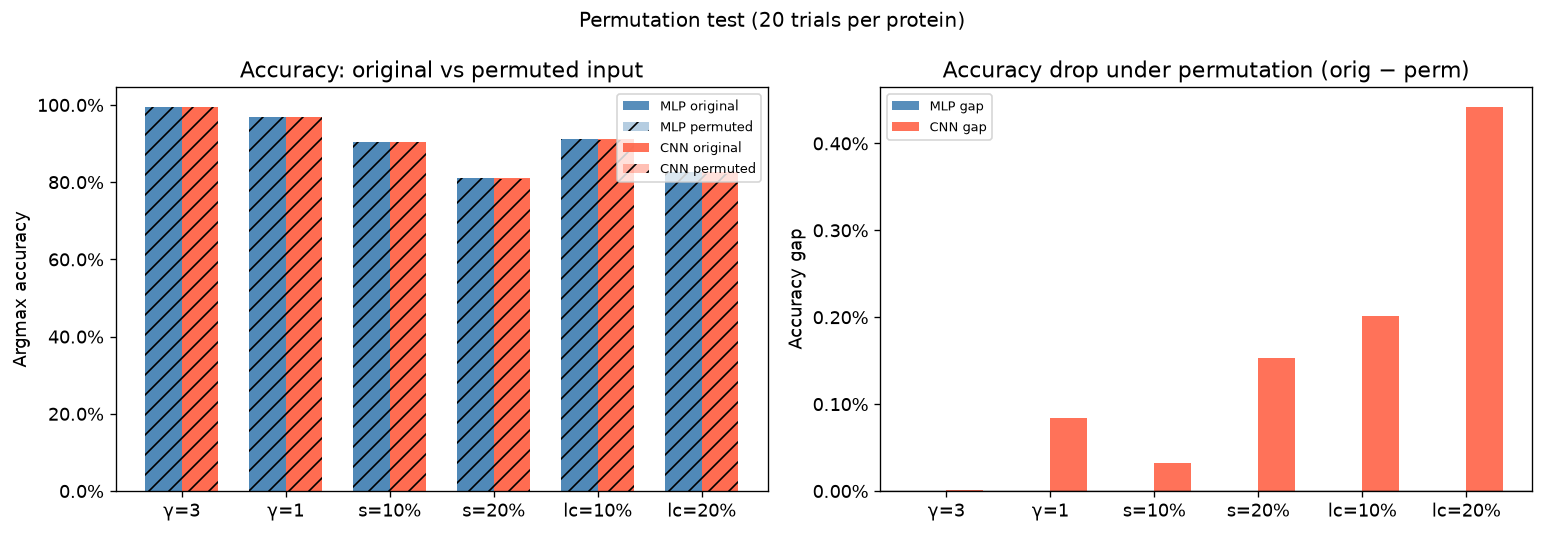

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(len(DATASETS))
w = 0.35

# Left: absolute accuracy orig vs perm
ax = axes[0]
mlp_orig = [perm_results[k]['mlp'][0] for k in DATASETS]
mlp_perm = [perm_results[k]['mlp'][1] for k in DATASETS]
cnn_orig = [perm_results[k]['cnn'][0] for k in DATASETS]
cnn_perm = [perm_results[k]['cnn'][1] for k in DATASETS]

ax.bar(x - w/2, mlp_orig, width=w, label='MLP original', color='steelblue',  alpha=0.9)
ax.bar(x - w/2, mlp_perm, width=w, label='MLP permuted', color='steelblue',  alpha=0.4, hatch='//')
ax.bar(x + w/2, cnn_orig, width=w, label='CNN original', color='tomato',     alpha=0.9)
ax.bar(x + w/2, cnn_perm, width=w, label='CNN permuted', color='tomato',     alpha=0.4, hatch='//')
ax.set_xticks(x); ax.set_xticklabels(LABELS)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=1))
ax.set(title='Accuracy: original vs permuted input', ylabel='Argmax accuracy')
ax.legend(fontsize=8)

# Right: gap (orig - perm)
ax = axes[1]
mlp_gap = [perm_results[k]['mlp'][0] - perm_results[k]['mlp'][1] for k in DATASETS]
cnn_gap = [perm_results[k]['cnn'][0] - perm_results[k]['cnn'][1] for k in DATASETS]
ax.bar(x - w/2, mlp_gap, width=w, label='MLP gap', color='steelblue', alpha=0.9)
ax.bar(x + w/2, cnn_gap, width=w, label='CNN gap', color='tomato',    alpha=0.9)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(LABELS)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=2))
ax.set(title='Accuracy drop under permutation (orig − perm)', ylabel='Accuracy gap')
ax.legend(fontsize=8)

fig.suptitle(f'Permutation test ({N_PERM} trials per protein)', fontsize=12)
fig.tight_layout()
plt.show()

## Test 2 — Confidence at Error Positions

At positions each model gets **wrong**, what is the max softmax probability?

A model that uses context effectively should be *less confident* at its remaining
errors — it should know when the signal is too ambiguous to call. If MLP and CNN
show identical confidence distributions at error positions, the CNN's receptive
field is not improving uncertainty quantification.

In [6]:
@torch.no_grad()
def confidence_at_errors(model, dataset_key):
    """
    Returns arrays of max-softmax confidence at wrong and correct positions.
    """
    ds  = ProteinDataset(H5_PATH, dataset_key, val_pids, aa_to_idx)
    ldr = DataLoader(ds, batch_size=BATCH, shuffle=False, collate_fn=collate_fn)

    conf_wrong, conf_right = [], []

    for probs, labels in ldr:
        probs, labels = probs.to(DEVICE), labels.to(DEVICE)
        mask   = labels != -1
        logits = model(probs)                          # (B, L, 20)
        softmx = F.softmax(logits, dim=-1)
        conf   = softmx.max(-1).values                 # (B, L)
        preds  = logits.argmax(-1)                     # (B, L)

        wrong = mask & (preds != labels)
        right = mask & (preds == labels)

        conf_wrong.extend(conf[wrong].cpu().tolist())
        conf_right.extend(conf[right].cpu().tolist())

    return np.array(conf_wrong), np.array(conf_right)

In [7]:
conf_results = {}  # key → {'mlp': (wrong, right), 'cnn': (wrong, right)}

# Run on hardest datasets only (most errors to analyse)
HARD = ['perturb_gamma1', 'scramble_20pct', 'lowconf_20pct']
HARD_LABELS = ['γ=1', 's=20%', 'lc=20%']

for key in HARD:
    mlp = load_mlp(key)
    cnn = load_cnn(key)
    conf_results[key] = {
        'mlp': confidence_at_errors(mlp, key),
        'cnn': confidence_at_errors(cnn, key),
    }
    mw, mr = conf_results[key]['mlp']
    cw, cr = conf_results[key]['cnn']
    print(f"{key}")
    print(f"  MLP — wrong: mean={mw.mean():.3f} median={np.median(mw):.3f}  n={len(mw):,}")
    print(f"  CNN — wrong: mean={cw.mean():.3f} median={np.median(cw):.3f}  n={len(cw):,}")

perturb_gamma1
  MLP — wrong: mean=0.790 median=0.827  n=3,786
  CNN — wrong: mean=0.794 median=0.828  n=3,665


scramble_20pct
  MLP — wrong: mean=0.708 median=0.758  n=22,826
  CNN — wrong: mean=0.770 median=0.808  n=22,774


lowconf_20pct
  MLP — wrong: mean=0.141 median=0.126  n=20,970
  CNN — wrong: mean=0.159 median=0.141  n=20,981


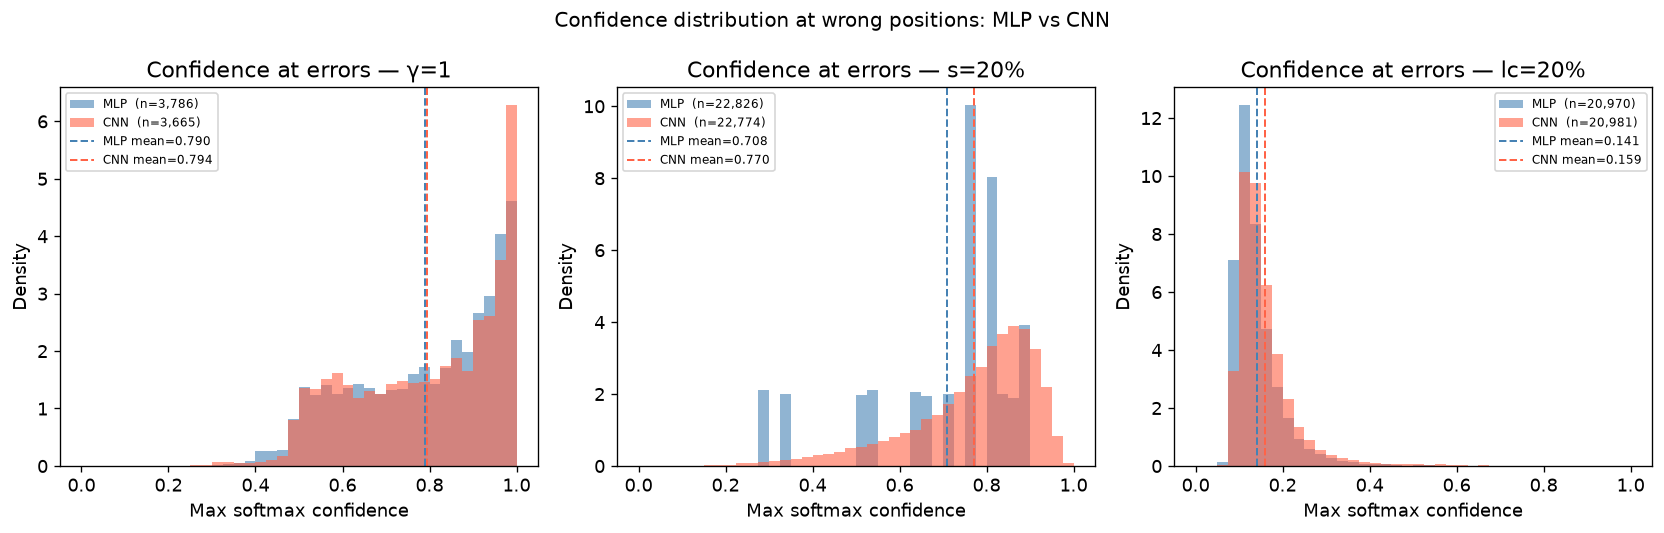

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
bins = np.linspace(0, 1, 41)

for ax, key, lbl in zip(axes, HARD, HARD_LABELS):
    mw, _ = conf_results[key]['mlp']
    cw, _ = conf_results[key]['cnn']

    ax.hist(mw, bins=bins, density=True, alpha=0.6, color='steelblue', label=f'MLP  (n={len(mw):,})')
    ax.hist(cw, bins=bins, density=True, alpha=0.6, color='tomato',    label=f'CNN  (n={len(cw):,})')

    ax.axvline(mw.mean(), color='steelblue', linestyle='--', linewidth=1.2,
               label=f'MLP mean={mw.mean():.3f}')
    ax.axvline(cw.mean(), color='tomato',    linestyle='--', linewidth=1.2,
               label=f'CNN mean={cw.mean():.3f}')

    ax.set(xlabel='Max softmax confidence', ylabel='Density',
           title=f'Confidence at errors — {lbl}')
    ax.legend(fontsize=7)

fig.suptitle('Confidence distribution at wrong positions: MLP vs CNN', fontsize=12)
fig.tight_layout()
plt.show()

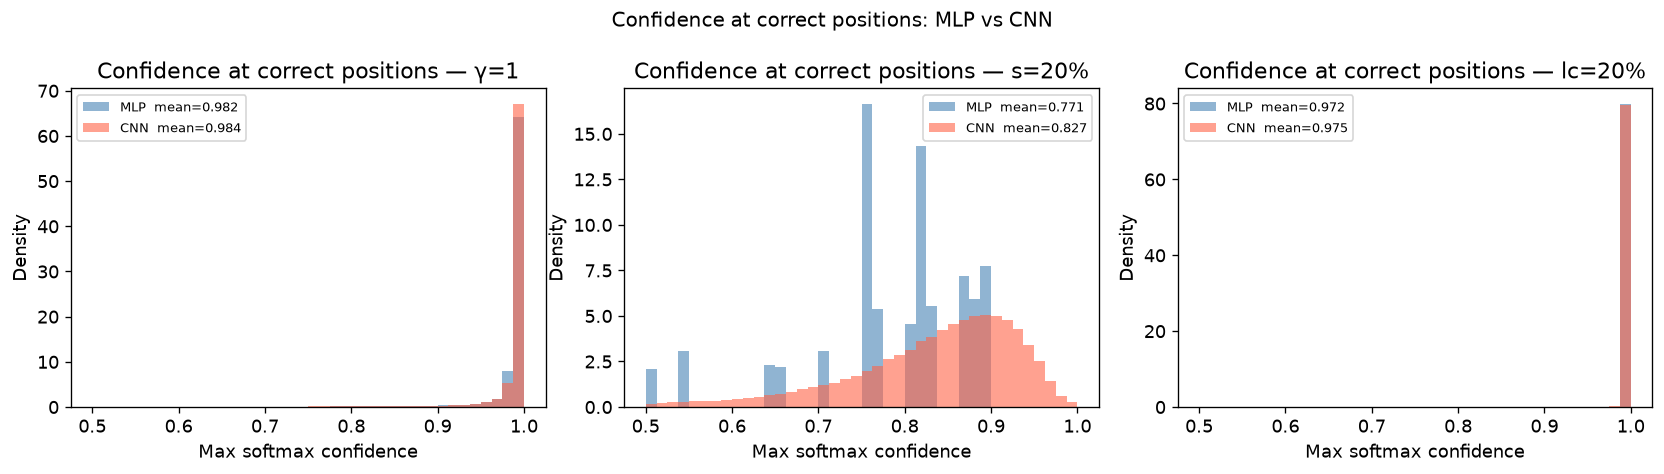

In [9]:
# Bonus: confidence at CORRECT positions — both should be high,
# but CNN should be higher if context helps it be more certain when it's right
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
bins_right = np.linspace(0.5, 1.0, 41)

for ax, key, lbl in zip(axes, HARD, HARD_LABELS):
    _, mr = conf_results[key]['mlp']
    _, cr = conf_results[key]['cnn']

    ax.hist(mr, bins=bins_right, density=True, alpha=0.6, color='steelblue',
            label=f'MLP  mean={mr.mean():.3f}')
    ax.hist(cr, bins=bins_right, density=True, alpha=0.6, color='tomato',
            label=f'CNN  mean={cr.mean():.3f}')
    ax.set(xlabel='Max softmax confidence', ylabel='Density',
           title=f'Confidence at correct positions — {lbl}')
    ax.legend(fontsize=8)

fig.suptitle('Confidence at correct positions: MLP vs CNN', fontsize=12)
fig.tight_layout()
plt.show()

## Interpretation

**Permutation test:**
- MLP gap ≈ 0 confirms position-invariance (sanity check).
- CNN gap > 0 → receptive field is being used. Gap = 0 → CNN is functionally an MLP.

**Confidence at errors:**
- If MLP and CNN distributions are identical → CNN not improving uncertainty quantification.
- CNN shifted left (less confident at errors) → model uses context to hedge on ambiguous positions.
- CNN shifted right (more confident at errors) → overconfident; context is misleading it.

## Test 3 — Centre-Occlusion Test (CNN only)

Replace position i's input with a uniform vector `[1/20, ..., 1/20]` — completely
removing the emission signal at that position — then measure whether the CNN can
still predict the correct AA at i using only its neighbours.

- If accuracy collapses to ~5% (1/20): CNN is not using context at all.
- If accuracy stays meaningfully above 5%: CNN is reading neighbouring positions to
  recover the occluded one.

Also compare the **logit shift** `model(x_occluded)[i] - model(x_original)[i]` to see
how much the prediction changes when position i loses its own signal.

In [ ]:
UNIFORM = 1.0 / 20   # value used to occlude a position

@torch.no_grad()
def occlusion_test(model, dataset_key, n_positions=50, seed=0):
    """
    For each val protein, sample up to n_positions positions uniformly at random.
    At each sampled position i:
      - replace p[i] with UNIFORM vector
      - compare predicted AA at i before vs after occlusion

    Returns:
      acc_orig   : accuracy at sampled positions with original input
      acc_occ    : accuracy at sampled positions with position i occluded
      logit_shift: mean L2 change in logit vector at i (how much prediction moves)
    """
    ds  = ProteinDataset(H5_PATH, dataset_key, val_pids, aa_to_idx)
    ldr = DataLoader(ds, batch_size=1, shuffle=False, collate_fn=collate_fn)
    rng = np.random.default_rng(seed)

    correct_orig = correct_occ = total = 0
    shifts = []

    for probs, labels in ldr:
        probs  = probs.to(DEVICE)    # (1, L, 20)
        labels = labels.to(DEVICE)   # (1, L)
        L = probs.shape[1]

        # Sample positions to test (avoid padding — none at batch_size=1)
        pos_sample = rng.choice(L, size=min(n_positions, L), replace=False)

        logits_orig = model(probs)   # (1, L, 20)

        for i in pos_sample:
            true_lbl = labels[0, i].item()

            # Original prediction at i
            pred_orig = logits_orig[0, i].argmax().item()
            correct_orig += int(pred_orig == true_lbl)

            # Occlude position i
            xp = probs.clone()
            xp[0, i] = UNIFORM
            logits_occ = model(xp)

            pred_occ = logits_occ[0, i].argmax().item()
            correct_occ += int(pred_occ == true_lbl)

            # L2 shift in logit vector at i
            shift = (logits_occ[0, i] - logits_orig[0, i]).norm().item()
            shifts.append(shift)

            total += 1

    return (correct_orig / total,
            correct_occ  / total,
            np.mean(shifts))

print('occlusion_test defined')

In [ ]:
occ_results = {}   # key → {'mlp': (orig, occ, shift), 'cnn': (orig, occ, shift)}

for key, lbl in zip(DATASETS, LABELS):
    mlp = load_mlp(key)
    cnn = load_cnn(key)

    mlp_res = occlusion_test(mlp, key)
    cnn_res = occlusion_test(cnn, key)
    occ_results[key] = {'mlp': mlp_res, 'cnn': cnn_res}

    print(f"{lbl:<8}  "
          f"MLP orig={mlp_res[0]:.3%}  occ={mlp_res[1]:.3%}  drop={mlp_res[0]-mlp_res[1]:+.3%}  shift={mlp_res[2]:.3f}  |  "
          f"CNN orig={cnn_res[0]:.3%}  occ={cnn_res[1]:.3%}  drop={cnn_res[0]-cnn_res[1]:+.3%}  shift={cnn_res[2]:.3f}")

print(f"\nRandom-chance baseline: {1/20:.1%}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(len(DATASETS))
w = 0.25

# Left: accuracy before/after occlusion for MLP and CNN
ax = axes[0]
ax.bar(x - 1.5*w, [occ_results[k]['mlp'][0] for k in DATASETS], width=w,
       label='MLP original', color='steelblue', alpha=0.9)
ax.bar(x - 0.5*w, [occ_results[k]['mlp'][1] for k in DATASETS], width=w,
       label='MLP occluded', color='steelblue', alpha=0.4, hatch='//')
ax.bar(x + 0.5*w, [occ_results[k]['cnn'][0] for k in DATASETS], width=w,
       label='CNN original', color='tomato', alpha=0.9)
ax.bar(x + 1.5*w, [occ_results[k]['cnn'][1] for k in DATASETS], width=w,
       label='CNN occluded', color='tomato', alpha=0.4, hatch='//')
ax.axhline(1/20, color='black', linestyle=':', linewidth=1.2, label='Random chance (5%)')
ax.set_xticks(x); ax.set_xticklabels(LABELS)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=1))
ax.set(title='Accuracy at occluded positions', ylabel='Argmax accuracy')
ax.legend(fontsize=7)

# Right: accuracy drop (orig - occ) = how much model relied on p_i
ax = axes[1]
ax.bar(x - w/2, [occ_results[k]['mlp'][0] - occ_results[k]['mlp'][1] for k in DATASETS],
       width=w, label='MLP drop', color='steelblue', alpha=0.9)
ax.bar(x + w/2, [occ_results[k]['cnn'][0] - occ_results[k]['cnn'][1] for k in DATASETS],
       width=w, label='CNN drop', color='tomato', alpha=0.9)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(LABELS)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=1))
ax.set(title='Accuracy drop after occlusion (orig − occ)', ylabel='Drop')
ax.legend(fontsize=8)

fig.suptitle('Centre-occlusion test: how much do models rely on p_i vs context?', fontsize=12)
fig.tight_layout()
plt.show()